In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline

In [14]:
"""DEFINE ACOUSTIC PARAMETERS"""
#Geometrical Propeller Parameters
prop_radius = 5*0.0254
hub_radius = 0.4*0.0254
n_blades = 2

#Fluid parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343

#Operating conditions
RPM = 5000
omega = 2*np.pi*RPM/60
v_inf = 0

#Read data from bemt
acoustic_input = pd.read_csv("acoustic_input.csv")
radial_section = acoustic_input['r']
n_sections = len(radial_section)
dr = acoustic_input['dr']
blade_angles = 2*np.pi/n_blades * np.arange(0, n_blades) #angle of blades in a frame rotating and translating with the propeller (frame is located on propeller axis)
airfoil_area = acoustic_input['A']

#Aerodynamic properties
dT = acoustic_input['dTdr']
dQ = acoustic_input['dQdr']
dR = np.zeros(len(dT))

#Temporal Discretization
period = 8 * (2*np.pi/omega) #time to complete one revolution 
n_source_times = 1000 #number of source times to be evaluated
dt = period/(n_source_times-1) #timestep size
src_times = np.arange(0,n_source_times)*dt #source times in seconds

In [15]:
"""COMPACT SOURCE ELEMENT FUNCTIONALITY"""
class CompactSourceElement:
    def __init__(self, rho, a_inf, dr, area, y0d, y1d, y2d, y3d, f0d, f1d, tau):
        self.rho = rho
        self.a_inf = a_inf
        self.dr = dr
        self.area = area
        self.y0d = y0d
        self.y1d = y1d
        self.y2d = y2d
        self.y3d = y3d
        self.f0d = f0d
        self.f1d = f1d
        self.tau = tau

    @classmethod
    def from_params(cls, rho, a_inf, r, blade_angle, dr, area, dT, dR, dQ, tau):
        y0dot = np.array([0, r * np.cos(blade_angle), r * np.sin(blade_angle)])
        y1dot = np.zeros(3)
        y2dot = np.zeros(3)
        y3dot = np.zeros(3)
        f0dot = np.array([dT, dR * np.cos(blade_angle) - dQ * np.sin(blade_angle), dR * np.sin(blade_angle) + dQ * np.cos(blade_angle)])
        f1dot = np.zeros(3)
        return cls(rho, a_inf, dr, area, y0dot, y1dot, y2dot, y3dot, f0dot, f1dot, tau)

    def transform(self, trans):
        y0d, y1d, y2d, y3d = trans(self.tau, self.y0d, self.y1d, self.y2d, self.y3d, linear_only=False)
        f0d, f1d = trans(self.tau, self.f0d, self.f1d, linear_only=True)
        return CompactSourceElement(self.rho, self.a_inf, self.dr, self.area, y0d, y1d, y2d, y3d, f0d, f1d, self.tau)

    def __repr__(self):
        return (f"CompactSourceElement(rho={self.rho}, a_inf={self.a_inf}, dr={self.dr}, area={self.area}, "
                f"y0d={self.y0d}, y1d={self.y1d}, y2d={self.y2d}, y3d={self.y3d}, "
                f"f0d={self.f0d}, f1d={self.f1d}, tau={self.tau})")

In [16]:
"""COORDINATE TRANSFORMATION FUNCTIONALITY"""
def coordinateTransform(tau, y0d, f0d, f1d, omega, v_inf):
    #define rotational and translational transformations
    y0d_nu = y0d
    angle = omega*tau
    x = v_inf*tau

    R0d = omega**0 * np.array([[1, 0, 0],
                               [0,  np.cos(angle), -np.sin(angle)],
                               [0,  np.sin(angle),  np.cos(angle)]
                               ])

    T0d = np.array([x, 0, 0])

    R1d = omega**1 * np.array([[0, 0, 0],
                               [0, -np.sin(angle), -np.cos(angle)],
                               [0, np.cos(angle), -np.sin(angle)]
                               ])
    
    T1d = np.array([v_inf, 0, 0])

    R2d = omega**2 * np.array([[0, 0, 0],
                               [0, -np.cos(angle), np.sin(angle)],
                               [0, -np.sin(angle), -np.cos(angle)]
                               ])
    
    T2d = np.zeros(3)

    R3d = omega**3 * np.array([[0, 0, 0],
                               [0, np.sin(angle), np.cos(angle)],
                               [0, -np.cos(angle), np.sin(angle)]
                               ])

    T3d = np.zeros(3)

    #apply transformations to quantities
    y0d = R0d @ y0d_nu + T0d
    y1d = R1d @ y0d_nu + T1d
    y2d = R2d @ y0d_nu + T2d
    y3d = R3d @ y0d_nu + T3d

    f0d = R0d @ f0d
    f1d = R1d @ f1d

    return y0d, y1d, y2d, y3d, f0d, f1d

In [17]:
"""CREATE COMPACT SOURCE ELEMENTS"""
# Initialize a 3D array of CompactSourceElement instances
compact_source_elements = np.empty((n_source_times, n_sections, n_blades), dtype=object)

for i in range(n_source_times):
    for j in range(n_sections):
        for k in range(n_blades):
            compact_source_elements[i, j, k] = CompactSourceElement.from_params(
                rho, a_inf, radial_section[j], blade_angles[k], dr[j], airfoil_area[j], -dT[j], dR[j], dQ[j], src_times[i]
            )

"""APPLY COORDINATE TRANSFORMATION"""
for i in range(n_source_times):
    for j in range(n_sections):
        for k in range(n_blades):
            element = compact_source_elements[i, j, k]
            y0d, y1d, y2d, y3d, f0d, f1d = coordinateTransform(tau=element.tau, y0d=element.y0d, f0d=element.f0d, f1d=element.f1d, omega=omega, v_inf=v_inf)
            # Create a new transformed element and replace the old one
            compact_source_elements[i, j, k] = CompactSourceElement(
                element.rho, element.a_inf, element.dr, element.area,
                y0d, y1d, y2d, y3d, f0d, f1d, element.tau
            )

In [18]:
"""ACOUSTIC OBSERVER FUNCTIONALITY"""
class AcousticObserver:
    def __init__(self, position_vector):
        self.position_vector = np.array(position_vector)

    def __call__(self):
        return self.position_vector
    
"""ADVANCED TIME CALCULATION"""
def advanced_time(source_elements, observer):
    observer_time = np.empty((n_source_times, n_sections, n_blades), dtype=object)
    for i in range(n_source_times):
        for j in range(n_sections):
            for k in range(n_blades):
                element = source_elements[i, j, k]
                r = np.linalg.norm(observer() - element.y0d)
                t = element.tau + r / element.a_inf
                observer_time[i, j, k] = t

    return observer_time

"""DEFINE OBSERVER"""
observer = AcousticObserver([0, 1, 0])

"""CALCULATE OBSERVER TIME"""
observer_time = advanced_time(compact_source_elements, observer)

In [19]:
"""COMPACT F1A CALCULATION"""
class F1AOutput:
    def __init__(self, t, p_m, p_d):
        self.t = t
        self.p_m = p_m
        self.p_d = p_d

def f1a(compact_elements, observer, observer_time):
    #observer position
    observer_position = observer()

    #0th order derivatives 
    r_vec_0d = observer_position - compact_elements.y0d
    r0d = np.linalg.norm(r_vec_0d)
    r_hat_0d = r_vec_0d / r0d
    v_vec_0d = compact_elements.y1d
    M_vec_0d = v_vec_0d / compact_elements.a_inf
    M0d = np.linalg.norm(v_vec_0d) / compact_elements.a_inf
    Mr_0d = np.dot(M_vec_0d, r_hat_0d)
    R_m1m2_0d = lambda m1, m2: r0d**(-m1) * (1 - Mr_0d)**(-m2)

    #1st order derivatives
    r_vec_1d = -compact_elements.y1d
    r1d = -np.dot(r_hat_0d, v_vec_0d)
    v_vec_1d = compact_elements.y2d
    M1d = 1/compact_elements.a_inf * np.dot(v_vec_0d, v_vec_1d) / (np.linalg.norm(v_vec_0d))
    r_hat_1d = -compact_elements.a_inf/r0d * (M_vec_0d - Mr_0d*r_hat_0d)
    Mr_1d = 1/compact_elements.a_inf * np.dot(v_vec_1d, r_hat_0d) + compact_elements.a_inf/r0d * (Mr_0d**2 - M0d**2)
    R_m1m2_1d = lambda m1, m2: (1/compact_elements.a_inf * np.dot(v_vec_1d, r_hat_0d) * m2 * R_m1m2_0d(m1, m2+1) + 
                               compact_elements.a_inf * m2 * (Mr_0d - M0d**2) * R_m1m2_0d(m1+1, m2+1) +
                               compact_elements.a_inf * (m1 - m2) * Mr_0d * R_m1m2_0d(m1+1, m2))


    #2nd order derivatives
    v_vec_2d = compact_elements.y3d
    R_11_2d = (1/compact_elements.a_inf * (np.dot(v_vec_2d, r_hat_0d) * R_m1m2_0d(1,2) + np.dot(v_vec_1d, r_hat_1d) * R_m1m2_0d(1,2) + np.dot(v_vec_1d,r_hat_0d) * R_m1m2_1d(1,2)) + 
              compact_elements.a_inf * (Mr_1d * R_m1m2_0d(2,2) + Mr_0d * R_m1m2_1d(2,2,) - 2*M0d*M1d*R_m1m2_0d(2,2) - M0d**2*R_m1m2_1d(2,2)))

    #Monopole coefficient
    C1A = R_m1m2_0d(0,2) * R_11_2d + R_m1m2_0d(0,1) * R_m1m2_1d(0,1) * R_m1m2_1d(1,1)

    # Dipole coefficients
    D1A = R_m1m2_0d(0,1)*R_m1m2_0d(1,1)*r_hat_0d
    E1A = R_m1m2_0d(0,1) * (R_m1m2_1d(1,1) * r_hat_0d + R_m1m2_0d(1,1) * r_hat_1d) + compact_elements.a_inf * R_m1m2_0d(2,1) * r_hat_0d

    # Monopole acoustic pressure
    p_m = compact_elements.rho / (4.0 * np.pi) * compact_elements.area * C1A * compact_elements.dr

    # Dipole acoustic pressure
    p_d = 1/(compact_elements.a_inf*4*np.pi) * (np.dot(compact_elements.f1d, D1A) * compact_elements.dr + np.dot(compact_elements.f0d, E1A) * compact_elements.dr)

    return F1AOutput(observer_time, p_m, p_d)

In [20]:
"""COMPUTE F1A OUTPUT FOR EACH COMPACT SOURCE ELEMENT"""
F1A_output = np.empty((n_source_times, n_sections, n_blades), dtype=object)
for i in range(n_source_times):
    for j in range(n_sections):
        for k in range(n_blades):
            element = compact_source_elements[i, j, k]
            observer_t = observer_time[i, j, k]
            F1A_output[i, j, k] = f1a(element, observer, observer_t)

In [21]:
"""COMBINE ACOUSTIC PRESSURE"""
class F1APressureTimeHistory:
    def __init__(self, t_common, p_m, p_d):
        self.t = t_common
        self.p_m = p_m
        self.p_d = p_d

def common_obs_time(f1a_output_array, time_range, n_common_time_steps):

    shape = f1a_output_array.shape
    t_obs = np.array([f1a_output_array[i, j, k].t for i in range(shape[0]) for j in range(shape[1]) for k in range(shape[2])]).reshape(shape)
    p_m = np.array([f1a_output_array[i, j, k].p_m for i in range(shape[0]) for j in range(shape[1]) for k in range(shape[2])]).reshape(shape)
    p_d = np.array([f1a_output_array[i, j, k].p_d for i in range(shape[0]) for j in range(shape[1]) for k in range(shape[2])]).reshape(shape)
    
    n_source_times = shape[0]
    n_sections = shape[1]
    n_blades = shape[2]

    time_matrix = np.empty((n_source_times, n_sections*n_blades)) #receiver times for each source element in columns
    pressure_matrix_m = np.empty((n_source_times, n_sections*n_blades)) #monopole pressure for each source element in columns
    pressure_matrix_d = np.empty((n_source_times, n_sections*n_blades)) #dipole pressure for each source element in columns
    for j in range(n_sections):
        for k in range(n_blades):
            time_matrix[:,2*j+k] = t_obs[:,j,k]
            pressure_matrix_m[:,2*j+k] = p_m[:,j,k]
            pressure_matrix_d[:,2*j+k] = p_d[:,j,k]

    #common starting time (max time for first recevier time of each source element)
    t_common_start = np.max(time_matrix[0,:])
    dt = time_range/n_common_time_steps
    #common time vector for all sources
    t_common = t_common_start + np.arange(n_common_time_steps) * dt
    return t_common, time_matrix, pressure_matrix_m, pressure_matrix_d

def combine(time_matrix, pressure_matrix_m, pressure_matrix_d, t_common):
    
    p_m_interp = np.zeros_like(t_common)
    p_d_interp = np.zeros_like(t_common)

    n_sources_tot = time_matrix.shape[1]
    for source in range(0,n_sources_tot):
        p_m_interp += np.interp(t_common, time_matrix[:,source], pressure_matrix_m[:,source])
        p_d_interp += np.interp(t_common, time_matrix[:,source], pressure_matrix_d[:,source])
    
    return F1APressureTimeHistory(t_common, p_m_interp, p_d_interp)

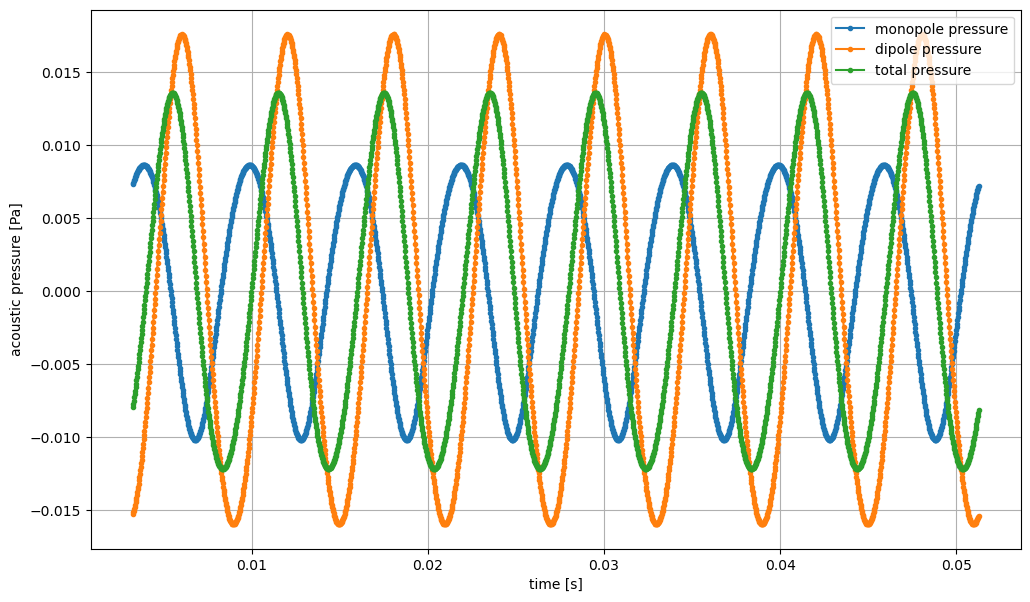

In [22]:
"""COMPUTE PRESSURE HISTORY AT SPECIFIC OBSERVER LOCATION"""
bpp = period/n_blades  # blade passing period
obs_time_range = bpp
num_obs_times = 2000

#Compute common observer time
t_common, time_matrix, pressure_matrix_m, pressure_matrix_d = common_obs_time(F1A_output, obs_time_range, num_obs_times)

#Combine acoustic pressure at observer location
pressure_history = combine(time_matrix, pressure_matrix_m, pressure_matrix_d, t_common)

fig, axs = plt.subplots(1,1)
fig.set_figheight(7)
fig.set_figwidth(12)
fontsize=10
labelsize=10

axs.plot(pressure_history.t, pressure_history.p_m, marker='.', label='monopole pressure')
axs.plot(pressure_history.t, pressure_history.p_d, marker='.', label='dipole pressure')
axs.plot(pressure_history.t, pressure_history.p_m+pressure_history.p_d, marker='.', label='total pressure')
axs.set_xlabel('time [s]', fontsize=fontsize)
axs.set_ylabel('acoustic pressure [Pa]', fontsize=fontsize)
axs.grid(True)
axs.legend()

In [33]:
h = compact_source_elements[0,0,0]
h

CompactSourceElement(rho=1.225, a_inf=343, dr=0.0015239999999999, area=5.3419248e-05, y0d=[0.      0.02794 0.     ], y1d=[ 0.          0.         14.62934979], y2d=[    0.         -7659.90963796     0.        ], y3d=[       0.                0.         -4010719.30762767], f0d=[-1.51232149  0.          1.73032052], f1d=[0. 0. 0.], tau=0.0)

In [23]:
"""DEFINE CLASS ACOUSTIC RECEIVER"""
class acousticReceiver:
    p_ref = 2*10**(-5) #Reference pressure according to CFD simulation

    #Init method reads raw data of a specific receiver and calculates SPL spectrum
    def __init__(self, data):
        self.rawData = data
        #self.rawData['Pressure'] = self.rawData['Pressure'] - self.rawData['Pressure'].mean() #subtract mean pressure value here
        self._fourierCharacteristics()

    #Method returns fourier characteristcs of pressure signal
    def _fourierCharacteristics(self):
        #Compute Fourier quantities
        self.dt = self.rawData.iloc[1,0] - self.rawData.iloc[0,0]
        self.n_points = len(self.rawData.iloc[:,0])
        self.frequency = np.fft.rfftfreq(self.n_points, self.dt)
        self.fft_pressure = np.fft.rfft(self.rawData.iloc[:,1])

        #Compute magnitude and phase of each complexe number
        self.fft_pressure_amplitude = np.absolute(self.fft_pressure) / self.n_points
        self.fft_pressure_phase = np.arctan2(self.fft_pressure.imag, self.fft_pressure.real)

    #Method returns time data
    def timeData(self):
        return self.rawData

    #Method returns SPL spectrum
    def SPL_Spectrum(self):
        #Z weigthed SPL
        self.SPL = 20 * np.log10(self.fft_pressure_amplitude/acousticReceiver.p_ref)
        #Write data in dataframe
        d = {'Frequency': self.frequency, 'SPL': self.SPL}
        SPL_spectrum = pd.DataFrame(data=d)
        return SPL_spectrum

    #Method returns A-weigthed SPL spectrum
    def SPLA_Spectrum(self):
        SPL_spectrum = self.SPL_Spectrum()
        #A weigthed SPL
        R_a = lambda f: (12194**2 * f**4) / ((f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2)*(f**2 + 737.9**2)) * (f**2 + 12194**2))
        A_weight = lambda f: 20*np.log10(R_a(f)) - 20*np.log10(R_a(1000))
        weight = np.array([A_weight(f) for f in self.frequency])
        self.SPL_A = SPL_spectrum['SPL'] + weight
        d = {'Frequency': self.frequency, 'SPL': self.SPL_A}
        SPL_spectrum = pd.DataFrame(data=d)
        return SPL_spectrum

    #Method returns overall SPL value
    def OSPL(self):
        self.SPL_Spectrum()
        pressure_amplitude = 10**(1/20 * self.SPL)*acousticReceiver.p_ref
        p_rms = np.sqrt(pressure_amplitude[0]**2 + 2*np.sum(pressure_amplitude[1:]**2))
        OSPL = 20*np.log10(p_rms/acousticReceiver.p_ref)   
        return OSPL
    
    #Method returns overall A-weighted SPL value -> Note that fluent calculates this value by only using the 5? highest values of the pressure amplitude vector!
    def OASPL(self):
        self.SPLA_Spectrum()
        pressure_amplitude = 10**(1/20 * self.SPL_A)*acousticReceiver.p_ref
        p_rms = np.sqrt(pressure_amplitude[0]**2 + 2*np.sum(pressure_amplitude[1:]**2))
        OASPL = 20*np.log10(p_rms/acousticReceiver.p_ref)
        return OASPL

    #Method returns overall SPL value calculated in time domain
    def OSPL_TimeDomain(self):
        time_vector = self.rawData.iloc[:,0]
        t_start  = time_vector.iloc[0]
        t_end = time_vector.iloc[-1]
        pressure_timeDomain = self.rawData.iloc[:,1]
        T = t_end - t_start
        InterObject = InterpolatedUnivariateSpline(time_vector, pressure_timeDomain**2, k = 3)
        p_rms_timeDomain = np.sqrt((1/T) * InterObject.integral(t_start, t_end))
        OSPL_timeDomain = 20*np.log10(p_rms_timeDomain/acousticReceiver.p_ref)
        return OSPL_timeDomain
    
    def A_weigthed_Pressure(self):
        #reconstruct pressure signal with weighted amplitude
        phase = self.fft_pressure_phase
        amplitude = 10**(1/20 * self.SPL_A)*acousticReceiver.p_ref * self.n_points
        pressure_fft_reconstructed = amplitude*np.exp(1j*phase)
        pressure_reconstructed = np.fft.irfft(pressure_fft_reconstructed)
        return pressure_reconstructed

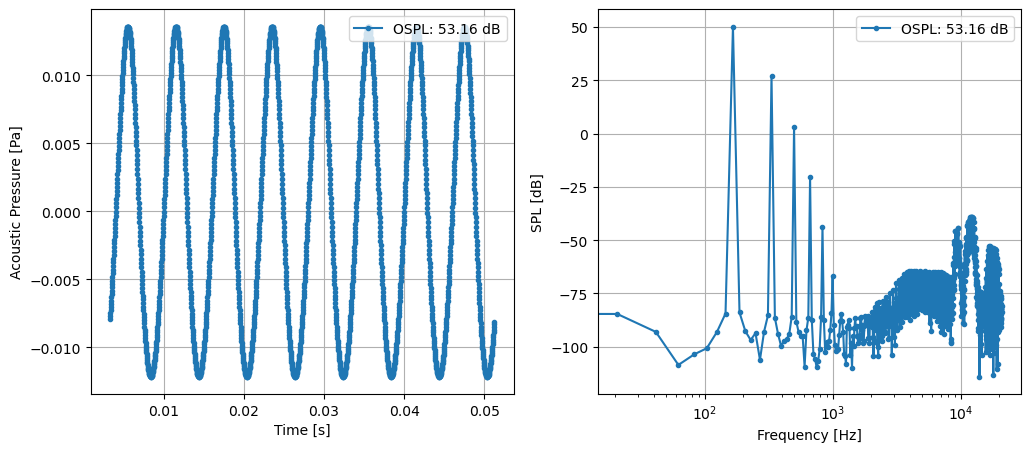

In [24]:
data = pd.DataFrame(np.array((pressure_history.t, pressure_history.p_m+pressure_history.p_d)).T, columns=['Time', 'Pressure'])

fig, axs = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(12)
fontsize=10
labelsize=10

Receiver = acousticReceiver(data)

axs[0].plot(Receiver.timeData()['Time'], Receiver.timeData()['Pressure'][0:], marker='.', label=f"OSPL: {np.round(Receiver.OSPL_TimeDomain(),2)} dB")
axs[1].semilogx(Receiver.SPL_Spectrum()['Frequency'], Receiver.SPL_Spectrum()['SPL'], marker='.', label=f"OSPL: {np.round(Receiver.OSPL(),2)} dB")

axs[0].set_xlabel(r'Time [s]', fontsize=fontsize)
axs[0].set_ylabel(r'Acoustic Pressure [Pa]', fontsize=fontsize)
axs[0].tick_params(axis='both', labelsize=labelsize)
axs[0].grid('on')
axs[0].legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=labelsize)

axs[1].set_xlabel(r'Frequency [Hz]', fontsize=fontsize)
axs[1].set_ylabel(r'SPL [dB]', fontsize=fontsize)
axs[1].tick_params(axis='both', labelsize=labelsize)
axs[1].grid('on')
axs[1].legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=labelsize)

In [290]:
import numpy as np
from scipy.io.wavfile import write

time_array = pressure_history.t
pressure_array = pressure_history.p_m + pressure_history.p_d

sampling_rate = int(1 / (time_array[1] - time_array[0]))  # samples per second
desired_duration = 5  # in seconds

num_repeats = int(np.ceil(desired_duration / (time_array[-1] - time_array[0])))

pressure_array_long = np.tile(pressure_array, num_repeats)
time_array_long = np.tile(time_array, num_repeats)

pressure_array_long = pressure_array_long[:int(sampling_rate * desired_duration)]

pressure_array_normalized = pressure_array_long / np.max(np.abs(pressure_array_long))
pressure_array_int16 = np.int16(pressure_array_normalized * 32767)

write('output.wav', sampling_rate, pressure_array_int16)